# CaF Spectra

In [3]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
from scipy import stats
from scipy.optimize import curve_fit
import scipy.signal as peak
from pathlib import Path
import matplotlib.ticker as ticker

# Append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")

# Import functions!!
import qil_helpers.Angela.angelaHelpers as ang

### Import .csv files

In [4]:
# folders sorted by wavelength
sites_1015 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2025-10-15\*\*\*\*'))
sites_1016_run1 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2025-10-16\caf\IH sites\run_1\*'))
sites_1016_run2 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2025-10-16\caf\IH sites\run_2\*'))
sites_1016_run3 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2025-10-16\caf\IH sites\run_3\*'))
sites_1018 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2025-10-18\*\*\*\*'))
sites_1025 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2025-10-25\*\*\*\*'))
sites_0203 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-03\*\*\*\*'))
sites_0204 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-04\*\*\*\*'))
motor_0206 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-06\caf\*'))
motor_0207 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-07\caf\*'))
sites_0210 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-10\caf\IH sites\run_6\*'))
sites_0211 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-11\caf\IH sites\run_8\*'))
sites_0212 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-02-12\caf\IH sites\run_1\*'))

print(len(sites_1015), 
      len(sites_1016_run1), 
      len(sites_1016_run2), 
      len(sites_1018), 
      len(sites_1025), 
      len(sites_0203),
      len(sites_0204),
      len(motor_0206),
      len(motor_0207),
      len(sites_0210),
      len(sites_0211), 
      len(sites_0212))

6 1 6 7 7 7 7 1 1 4 4 4


### Plotting Functions

In [160]:
# LORENTZIAN FITTING
def asym_lorentzian(x, x0, gamma, A, B, C):
    x = np.asarray(x, dtype = float)
    x0 = float(x0)
    gamma = float(gamma)
    A = float(A)
    B = float(B)
    C = float(C)
    arg = 2*(x - x0)/gamma
    return A * ((1 + B * arg)**2 + B**2)/(1 + arg**2) + C

def asym_lorentzian_fit(data, mask):    
    # unpack data from input
    x = data[:, 0]
    y = data[:, 1]

    # create a boolean mask to identify valid (non-NaN) data points
    valid_mask = ~np.isnan(x) & ~mask
    x_filtered = x[valid_mask]
    y_filtered = y[valid_mask]

    # initial guess for parameters
    x0_guess = x_filtered[np.argmax(y_filtered)]
    gam_guess = (x_filtered.max() - x_filtered.min()) / 10
    A_guess = np.max(y_filtered) - np.min(y_filtered)
    B_guess = 0
    C_guess = np.min(y_filtered)
    p0 = [x0_guess, gam_guess, A_guess, B_guess, C_guess]

    # fit lorentzian to data
    popt, pcov = curve_fit(asym_lorentzian, 
                           x_filtered, 
                           y_filtered,
                           p0 = p0,
                           maxfev = int(1e5))
    x0 = [popt[0], np.sqrt(pcov[0,0])]   
    gamma = [popt[1], np.sqrt(pcov[1,1])]   
    A = [popt[2], np.sqrt(pcov[2,2])]   
    B = [popt[3], np.sqrt(pcov[3,3])]
    C = [popt[4], np.sqrt(pcov[4,4])]

    return x0, gamma, A, B, C

# PLOT SPECTRA BY SITES
def spectra_by_freq(folderPath, numBins, intTime, excTime, aom, lines, linesLabel, ylims, fit, fit_which_bins, cols, save, savePath, desc):
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    folderDates = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders]
    
    # DATA
    all_freqsVpeaks = {}
    all_fits = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        freqs = np.array(freqs)
        peaks = np.array(peaks)
        pVs = np.array(pVs) 
        is_saturated = np.array(is_saturated)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')
        centreFreq = np.mean(freqs)
        linesDetuned = (lines[i])*1e3 - (centreFreq)/1e3  # detuning in GHz

        # PLOT 
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter((freqs - centreFreq + aom) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} ms'], 
                        c = cols[0], s = 5) 
        norm_ax.vlines(linesDetuned/1e3, 0, ylims[i][1], 
                    colors = cols[2], label = linesLabel[i])
        norm_ax.set_xlabel(fr'Detuning from {centreFreq/1e6:.3f} THz (GHz)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')
        
        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack(((freqs[which_bins] - centreFreq)/1e3, peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot((freqs - centreFreq + aom) / 1e3, 
                asym_lorentzian((freqs - centreFreq + aom) / 1e3, x0[0], gamma[0], A[0], B[0], C[0]),
                c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} GHz')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad=1, loc = 'upper left')

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi=  300, bbox_inches = 'tight')
        all_freqsVpeaks[wave] = freqsVpeaks
        all_fits[wave] = fits
        plt.show()
        
    return all_freqsVpeaks, all_fits

def spectra_by_pV(folderPath, numBins, intTime, excTime, aom, 
                  lines, linesLabel, ylims, fit, fit_which_bins, 
                  cols, save = False, savePath = None, desc = None, lifetimes = None):
    """
    Plots spectra by sites. Optionally saves plots in designated folder. 
    Returns dictionaries of:
        - Frequency vs. counts, indexed by toptica wavelength.
        - Fitted lineshape parameters.
    """
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    
    # DATA
    all_pVsVpeaks = {}
    all_fits_by_pVs = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        pVs = np.array(pVs) 
        peaks = np.array(peaks)
        is_saturated = np.array(is_saturated)
        pVsVpeaks = pd.DataFrame(np.vstack((pVs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        pVsVpeaks = pVsVpeaks.rename(columns = {0: r'Piezo Voltage (V)', 1: fr'Counts over {timeLimit*1e3} ms'})
        pVsVpeaks = pVsVpeaks.sort_values(by = r'Piezo Voltage (V)')

        # PLOT SPECTRUM
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter(pVs, pVsVpeaks[fr'Counts over {timeLimit*1e3} ms'], c = cols[0], s = 5) 
        norm_ax.set_xlabel(fr'Piezo Voltage at {wave} nm centre (V)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')

        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack((pVs[which_bins], peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot(pVs, 
                        asym_lorentzian(pVs, x0[0], gamma[0], A[0], B[0], C[0]),
                        c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} V')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad = 1, loc = 'upper left')

        # PLOT LIFETIMES
        if lifetimes is not None:
            life_ax = fig.add_subplot(2, 1, 2)
            life_ax.scatter(pVs, lifetimes, c = 'magenta', s = 5) 

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
        
        all_pVsVpeaks[wave] = pVsVpeaks
        all_fits_by_pVs[wave] = fits
        plt.show()
        
    return all_pVsVpeaks, all_fits_by_pVs

### PROCESS MOTOR DATA ###
def process_motor(dataPath, numBins, ylims, save, dataID, savePath):
    sortedFolders = sorted(dataPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]

    # DATA 
    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            maxLim = ylims[1]

            # IGNORE SATURATED COUNTS - better to set 0 or NaN?
            if counts > maxLim:
                counts = 0
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        freqs = np.array(freqs)
        peaks = np.array(peaks)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')

        # SAVE DATA
        if save:
            os.makedirs(savePath, exist_ok = True)
            filePath = os.path.join(savePath, fr'{dataID}.csv')
            freqsVpeaks.to_csv(filePath)

    return freqsVpeaks, timeLimit

### PLOT SPECTRA OVER MOTOR SCAN ## 
def plot_motor(datadf, numBins, where, 
               intTime, excTime, timeLimit, aom, 
               ylims, cols, save, plotPath, plotDesc, motorID, 
               lines = None, foundLines = None, linesLabel = None, lifeVfreqs = None):
    """
    Input dataframe to plot spectra by over wide motor scan. Optionally saves plots in designated folder. 
    If sites are known or identified, they can be labelled and plotted. 
    Returns plot of spectrum.
    """
    c = 299792458

    def wavelengthToFreq(wavelength):
        wavelength = np.asarray(wavelength, dtype=float)
        freq = np.empty_like(wavelength)
        freq[:] = np.nan
        mask = wavelength > 0
        freq[mask] = c / wavelength[mask]

        return freq
    
    def freqToWavelength(freq):
        freq = np.asarray(freq, dtype=float)
        wl = np.empty_like(freq)
        wl[:] = np.nan
        mask = freq > 0
        wl[mask] = c / freq[mask]

        return wl

    # EXTRACT DATA
    freqs_raw = np.asarray(datadf['Frequencies (MHz)'])
    peaks_raw = np.asarray(datadf[fr'Counts over {timeLimit*1e3} ms'])
    sort_idx = np.argsort(freqs_raw)
    freqs = freqs_raw[sort_idx]
    peaks = peaks_raw[sort_idx]

    if lifeVfreqs is not None:
        fig, (freq_ax, life_ax) = plt.subplots(
            2, 1, figsize = (16, 10), sharex = True)
    else:
        fig, freq_ax = plt.subplots(figsize=(16, 8))
        life_ax = None

    # PLOT SPECTRUM
    wave_ax = freq_ax.secondary_xaxis('top', functions = (freqToWavelength, wavelengthToFreq))
    wave_ax.tick_params(labelsize = 10)
    wave_ax.set_xlabel('Wavelength (nm)', fontsize = 12)
    freq_ax.grid(alpha = 0.1, which = 'minor')
    freq_ax.grid(alpha = 0.8, which = 'major')
    freq_ax.scatter(((freqs[where[0]:where[1]] + aom) / 1e3), peaks[where[0]:where[1]], 
                    c = cols[0], s = 1, alpha = 1) 
    if foundLines is not None:
        freq_ax.vlines(np.array(foundLines)/1e3, 0, ylims[1], 
                colors = 'red', alpha = 0.6, linewidths = 1.5)
    if linesLabel is not None:
        freq_ax.vlines(np.array(lines)/1e3, 0, ylims[1], 
            colors = cols[2], linewidths = 1.2)
    freq_ax.set_xlim([freqs[where[0]]/1e3 - 10, freqs[where[1]]/1e3 + 10])
    freq_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {int(excTime*1e3)}ms Excitation', fontsize = 12)
    freq_ax.set_ylim([0, ylims[1]])
    freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
    freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # PLOT LIFETIMES
    if lifeVfreqs is None:
        freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5e3))
        freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    if lifeVfreqs is not None:
        life_ax.grid(alpha = 0.1, which = 'minor')
        life_ax.grid(alpha = 0.8, which = 'major')
        life_ax.scatter(lifeVfreqs[:, 0]/1e3, lifeVfreqs[:, 1], c = 'OrangeRed', s = 1) 
        life_ax.set_ylim([0, 6.5])
        life_ax.set_ylabel(f'T1 (ms)', fontsize = 12)
        life_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
        life_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # SAVE 
    if save == True:
        save_path_png = os.path.join(plotPath, f'motor_run{motorID}_{numBins}bins.png')
        os.makedirs(plotPath, exist_ok = True)
        plt.savefig(save_path_png, 
                    dpi = 300, bbox_inches='tight')

    # PLOT FORMATTING
    plt.xlabel('Frequency (GHz)', fontsize = 12)
    plt.suptitle(fr'{plotDesc}', fontsize = 18)
    plt.tight_layout()
    plt.show()
    return

################################################################################
# Peak picking
save_path = "data processed\peak picking data"
os.makedirs(save_path, exist_ok=True)
stop_picking = False
selected_points = []

def onclick(event, freqs, counts):
    if event.xdata and event.ydata:
        # Find the nearest point to the clicked x-coordinate (frequency)
        freq_clicked = event.xdata
        count_clicked = np.interp(freq_clicked, freqs, counts)
        selected_points.append((freq_clicked, count_clicked))

def onkey(event, freqs, counts):
    global stop_picking
    if event.key == 'e':
        stop_picking = True
        plt.close()

def save_selected_points(description='peak'):
    peak_name = input("Enter the peak name: ")
    timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    filename = f"{timestamp}_{description}_{peak_name}.csv"
    df = pd.DataFrame(selected_points, columns=['Frequency (GHz)','Signal'])
    file_path = os.path.join(save_path, filename)
    df.to_csv(file_path, index=False)
    print(f'Saved selected points to {filename}')

def find_IH_peaks_with_click(freqs_array, counts_array, where, desc):
    global counts, freqs, stop_picking
    selected_points.clear()
    stop_picking = False
    print("Click on the graph to select peaks. Press 'e' to complete selection.")

    while stop_picking is False:
        # Regular plotting
        fig, ax = plt.subplots(figsize=(20, 12))
        freqs = freqs_array[where[0]:where[1]]
        counts = counts_array[where[0]:where[1]]
        ax.scatter(freqs, counts)
        ax.set_xlabel('Frequency (GHz)')
        ax.set_ylabel('Counts')
        ax.set_xticks
        ax.set_title(f'Peak Picking!')
        ax.grid(True)

        # Manually select peaks
        cid_click = fig.canvas.mpl_connect('button_press_event', 
                                        lambda event, f = freqs, c = counts: onclick(event, f, c))
        cid_key = fig.canvas.mpl_connect('key_press_event', 
                                        lambda event, f = freqs, c = counts: onkey(event, f, c))
        plt.show(block = False)
        plt.waitforbuttonpress()
        plt.close()
    save_selected_points(desc)
    

In [4]:
linesFreq = [195.34697, 195.42657, 196.08637, 197.52763] # From Alexey's paper
wavelengths = [1534.583, 1533.938, 1528.813, 1517.641]
linesLabel = [r'a1', 'a2', 'a3', 'a7']

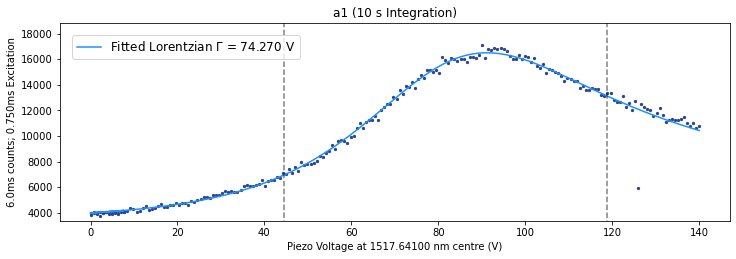

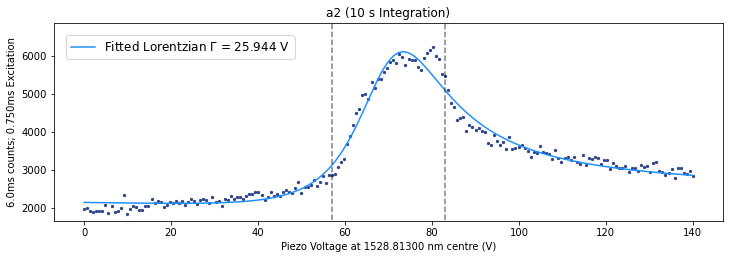

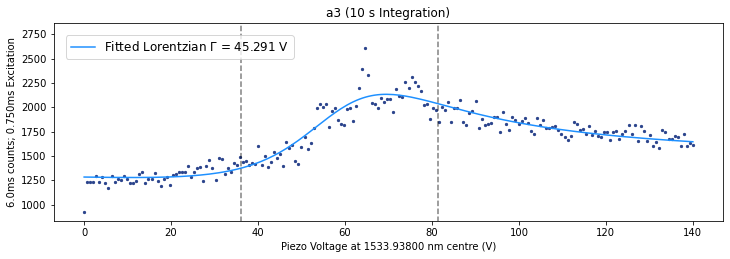

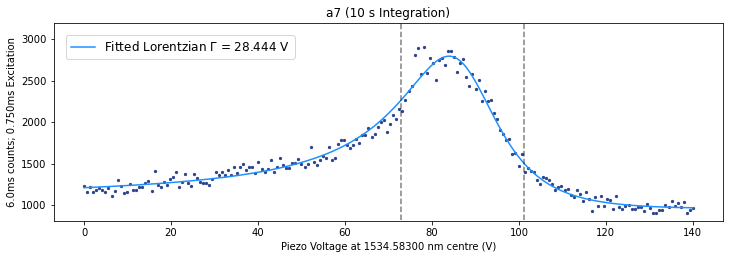

In [ ]:
ylims_0310 = [[0, 2e4], 
              [0, 8e3], 
              [0, 4e3], 
              [0, 4e3]]

fVp_0310, fits_0310 = spectra_by_pV(
    folderPath = sites_0310,
    numBins = 300,
    intTime = 10,
    excTime = 0.75e-3,
    aom = 380, # MHz
    lines = linesFreq,
    linesLabel = linesLabel,
    ylims = ylims_0310,
    cols = ['#2B448C', 'dodgerblue', 'OrangeRed', 'orange'],
    fit = True,
    fit_which_bins = [0, -1],
    save = False,
    savePath = sites_0310, # need to define savepath
    desc = linesLabel) 

In [9]:
# fits = [x0, gamma, A, B, C]
fits_a1 = fits_0310['1517.64100']
fits_a2 = fits_0310['1528.81300']
fits_a3 = fits_0310['1533.93800']
fits_a7 = fits_0310['1534.58300']

# Motor Scan

### Run 1 

In [155]:
ylims_0317 = [0, 1.5e4]
numBins = 200

# PROCESS PEAKS DATA
fVp_0317, timeLimit_0317 = process_motor(motor_0317,
                           numBins = numBins,
                           ylims = ylims_0317,
                           save = True,
                           dataID = 'sic_motor_run1',
                           savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\motor')

# EXTRACT RELEVANT ARRAYS
motor_freqs = fVp_0317['Frequencies (MHz)']
motor_peaks = fVp_0317['Counts over 4.0 ms']

KeyboardInterrupt: 

In [ ]:
### NORMALISE DATA TO COUNTS PER SECOND IN PROCESS_MOTOR

In [98]:
# Find peaks
%matplotlib
plt.ion()
find_IH_peaks_with_click(motor_freqs, motor_peaks, 
                         where= [8000, 10000],
                         desc = 'sic_motor_run1')

Using matplotlib backend: QtAgg
Click on the graph to select peaks. Press 'e' to complete selection.
Saved selected points to 2026_04_01_01_23_13_sic_motor_run1_bins8000_10000.csv


In [ ]:
d = {"col1": [0, 1, 2, 3], "col2": pd.Series([2, 3], index=[2, 3])}
pd.DataFrame(data=d, index=[0, 1, 2, 3])

In [154]:
# Concatenate found peaks
sic_motor = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\motor\*'))
foundFreqs_0317 = np.array([])
foundPeaks_0317 = np.array([])

for file in sic_motor:
    data = pd.read_csv(file)
    freqs = np.array(data['Frequency (GHz)'])
    foundFreqs_0317 = np.concatenate((foundFreqs_0317, freqs))
    peaks = np.array(data['Signal'])
    foundPeaks_0317 = np.concatenate((foundPeaks_0317, peaks))
    found_lines = pd.DataFrame({'Frequency (MHz)': foundFreqs_0317, 
                                'Counts': foundPeaks_0317})

found_lines.to_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\motor\found_lines.csv')
# np.savetxt('found_lines.csv', foundFreqs_0317, delimiter = ',')

In [164]:
# %matplotlib inline
%matplotlib
# plt.ion()
# plt.ioff()

# PLOT DATA
plot_motor(fVp_0317,
           numBins = 200,
           where = where,
           intTime = 4.5,
           excTime = 1e-3,
           timeLimit = timeLimit_0317,
           aom = 380,
           ylims = ylims_0317,
           cols = ['#2B448C', 'dodgerblue', 'OrangeRed'],
           save = True,
           plotPath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2026-03-17\sic\motor',
           plotDesc = fr'Implanted 4H Er:SiC in Confocal (4.5 s Integration)',
           motorID = 1, 
        #    foundLines = foundFreqs_0317,
           lifeVfreqs = lifeVfreqs)

Using matplotlib backend: QtAgg


### Run 2

In [33]:
ylims_0318 = [0, 1e6]
numBins = 200

# PROCESS DATA
fVp_0318, timeLimit_0318 = process_motor(motor_0318,
                           numBins = numBins,
                           ylims = ylims_0318,
                           save = True,
                           dataID = 'sic_motor_run2',
                           savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-18\sic\motor')

165    195496193.0
Name: Frequencies (MHz), dtype: float64


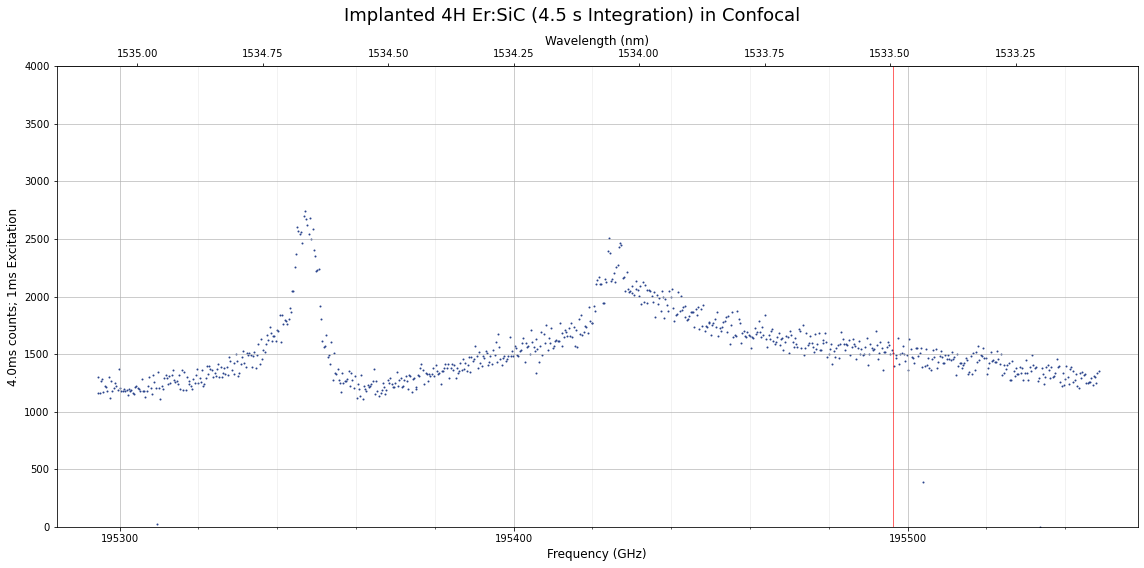

In [ ]:
# FIND PEAKS
%matplotlib inline
peaks_0318 = fVp_0318[f'Counts over {timeLimit_0318 * 1e3} ms']
foundPeaks_0318 = peak.find_peaks(peaks_0318, 
                height = [2500, 3000],
                width = 20,
                prominence = 0.8 * np.max(peaks_0318))[0]
foundFreqs_0318 = fVp_0318[f'Frequencies (MHz)'][foundPeaks_0318]
print(foundFreqs_0318)

# PLOT DATA
plot_motor(fVp_0318,
           numBins = 200,
           where = [0, len(fVp_0318) - 1],
           intTime = 4.5,
           excTime = 1e-3,
           timeLimit = timeLimit_0318,
           aom = 380,
           ylims = [0, 4e3],
           cols = ['#2B448C', 'dodgerblue', 'OrangeRed'],
           save = False,
           plotPath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2026-03-17\sic\motor',
           plotDesc = fr'Implanted 4H Er:SiC (4.5 s Integration) in Confocal',
           motorID = 2,
           foundLines = foundFreqs_0318)

# Lifetimes

In [25]:
cols = ['#2B448C', '#CE5F2C', 'dodgerblue', 'OrangeRed']

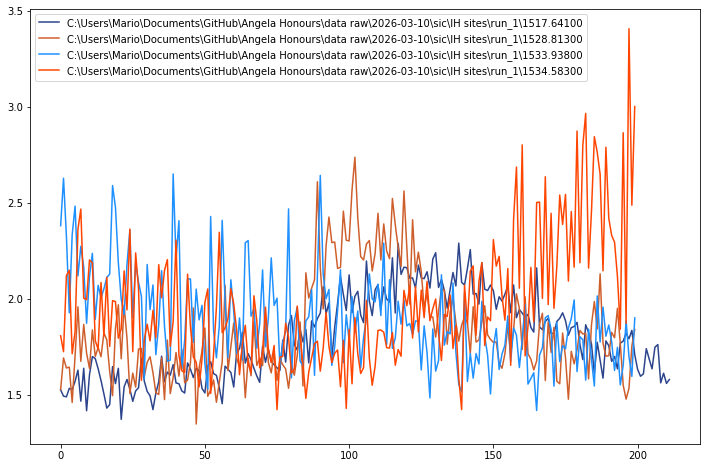

Time limit: 3.00 ms


In [26]:
%matplotlib inline

lifetime_dict = {}
plt.figure(figsize = (12, 8))

for j, folder_path in enumerate(sites_0310):
    
    files = os.listdir(folder_path)
    lifetimes = np.zeros(len(files))
    
    for i, file in enumerate(files):
        filepath = os.path.join(folder_path, file)
        data = np.loadtxt(filepath, delimiter=',')

        xA = data[0, 0:150]
        yA = data[1, 0:150]

        maskA = yA > 0
        xA = xA[maskA]
        yA = yA[maskA]

        slopeA, interceptA, *_ = stats.linregress(xA, np.log(yA))        
        
        lifetimes[i] = -(1/slopeA) * 1e3  # ms

    # use folder name as key (or replace with wavelength if encoded)
    lifetime_dict[folder_path] = lifetimes
    plt.plot(np.arange(len(files)), lifetimes, c=cols[j], label=f"{folder_path}")

plt.legend()
plt.show()

print(f'Time limit: {data[0, 150]*1e3:.2f} ms')

In [27]:
# DEFINE FUNCTION FOR EXTRACTING LIFETIMES, SORTED BY FREQUENCY
lifeVfreqs = np.zeros((len(os.listdir(motor_0317[0])), 2))
folder_path = motor_0317[0]
files = os.listdir(folder_path)

for i, file in enumerate(files):
    filepath = os.path.join(folder_path, file)
    data = np.loadtxt(filepath, delimiter=',')
    lifeVfreqs[i, 0] = float(file.split("_")[2]) # store frequencies
    xA = data[0, 0:150]
    yA = data[1, 0:150]
    maskA = yA > 0
    xA = xA[maskA]
    yA = yA[maskA]
    try:
        slopeA, interceptA, *_ = stats.linregress(xA, np.log(yA)) 
        lifeVfreqs[i, 1] = -(1/slopeA) * 1e3  # ms
    except Exception as e:
        lifeVfreqs[i, 1] = 1e-3      

print(f'Time limit: {data[0, 150]*1e3:.2f} ms')

C:\Users\Mario\AppData\Local\Temp\ipykernel_13232\1941288492.py:17: RuntimeWarning: divide by zero encountered in double_scalars
  lifeVfreqs[i, 1] = -(1/slopeA) * 1e3  # ms


Time limit: 3.00 ms


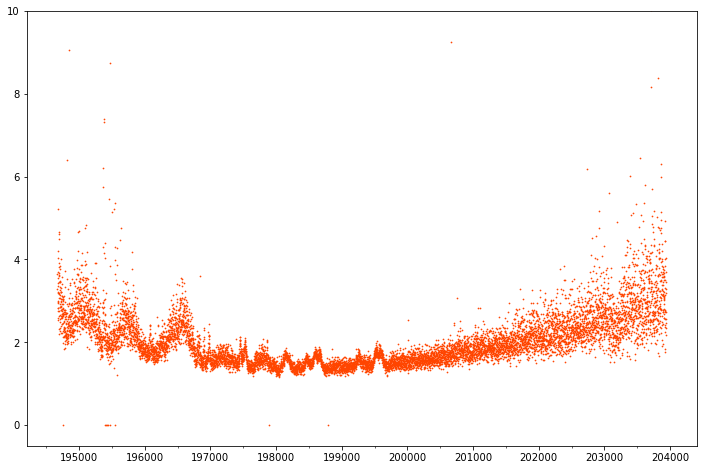

In [28]:
%matplotlib inline
plt.ioff()

fig, ax = plt.subplots(figsize = (12, 8))
ax.scatter(lifeVfreqs[:, 0]/1e3, lifeVfreqs[:, 1],
             c = cols[3], s = 0.5)
ax.set_ylim([-0.5, 10])
ax.xaxis.set_major_locator(ticker.MultipleLocator(1e3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5e3))
plt.show()